In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

##### Carga del dataset

In [8]:
df = pd.read_csv('../../../data/Mall_customers.csv')
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


##### Seleccion de variables

In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Escalamos los datos para que ambas variables tengan la misma importancia
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##### Implementacion K-Means

c:\Users\Ivan\miniconda3\envs\deep_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ivan\miniconda3\envs\deep_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ivan\miniconda3\envs\deep_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Ivan\miniconda3\envs\deep_learning\lib\site-packages\sklearn\cluster\_

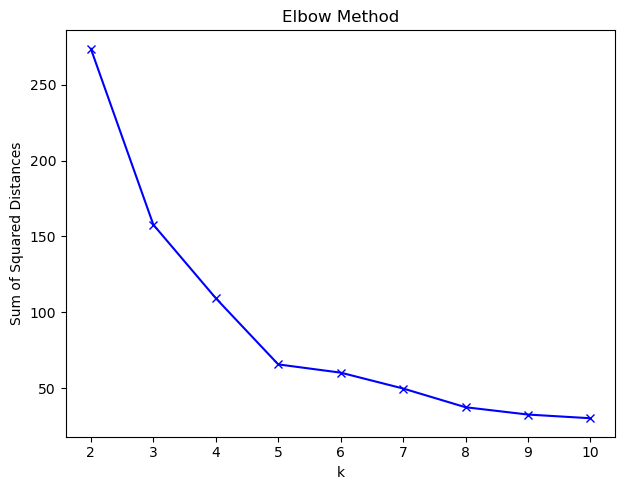

In [11]:
#Determinacion y pruebas con valor de K
sse = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)
    if k > 1:  # Silhouette score needs at least 2 clusters
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Visualización del Elbow Method
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K, sse, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')

plt.tight_layout()
plt.show()

* Se determina de acuerdo al metodo del codo, que el mejor valor para k es 5

##### Implementacion K-Means

c:\Users\Ivan\miniconda3\envs\deep_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


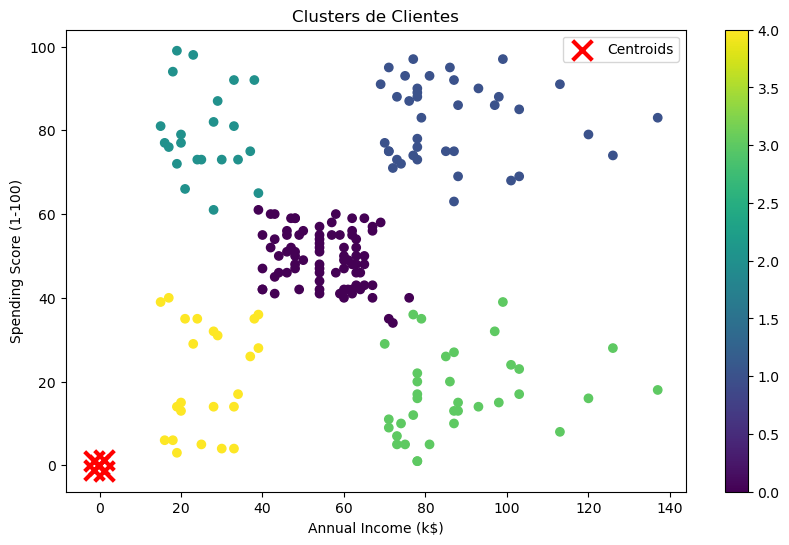

In [12]:
k_optimo = 5
kmeans = KMeans(n_clusters=k_optimo, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Visualización de los clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            marker='x', s=200, linewidths=3, color='r', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Clusters de Clientes')
plt.colorbar(scatter)
plt.legend()
plt.show()

Analisis de clusters

* Cluster Púrpura (Centro):

Ingresos medios (40-80k$)
Puntaje de gasto medio (40-60)
Este parece ser el grupo más grande y representa clientes "promedio" con hábitos de gasto moderados en relación a sus ingresos.

* Cluster Azul (Superior Derecho):

Ingresos altos (70-140k$)
Puntaje de gasto alto (60-100)
Representa a los clientes "premium" que tienen altos ingresos y gastan una proporción significativa de ellos en el mall.

* Cluster Verde (Inferior Derecho):

Ingresos altos (70-140k$)
Puntaje de gasto bajo (5-40)
Son clientes con alto poder adquisitivo pero conservadores en sus gastos, posiblemente ahorradores o que prefieren gastar en otros lugares.

* Cluster Turquesa (Superior Izquierdo):

Ingresos bajos (15-40k$)
Puntaje de gasto alto (60-100)
Representan clientes que, a pesar de tener ingresos más bajos, tienen una alta propensión al gasto en el mall.

* Cluster Amarillo (Inferior Izquierdo):

Ingresos bajos (15-40k$)
Puntaje de gasto bajo (5-40)
Clientes con recursos limitados y gastos conservadores.

##### Analisis detallado de clusters


Estadísticas por Cluster:
        Annual Income (k$)          Spending Score (1-100)         CustomerID
                      mean min  max                   mean min max      count
Cluster                                                                      
0                    55.30  39   76                  49.52  34  61         81
1                    86.54  69  137                  82.13  63  97         39
2                    25.73  15   39                  79.36  61  99         22
3                    88.20  70  137                  17.11   1  39         35
4                    26.30  15   39                  20.91   3  40         23


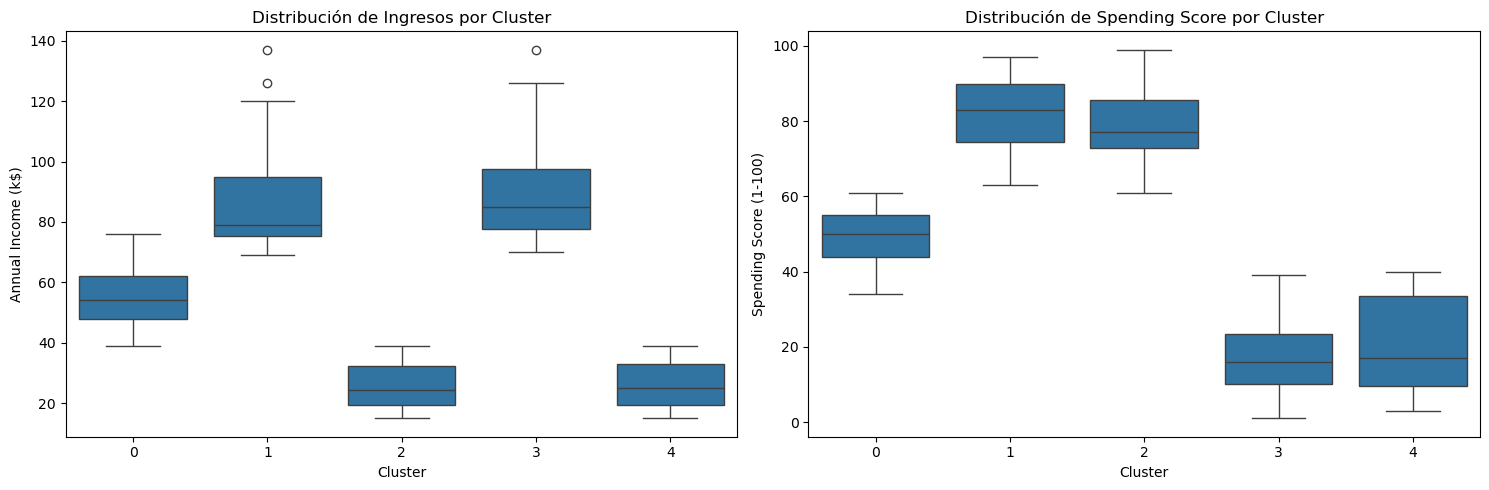

In [13]:
df['Cluster'] = clusters
cluster_stats = df.groupby('Cluster').agg({
    'Annual Income (k$)': ['mean', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'min', 'max'],
    'CustomerID': 'count'
}).round(2)

print("\nEstadísticas por Cluster:")
print(cluster_stats)

# 6. Visualización adicional: distribución de variables por cluster
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución de ingresos por cluster
sns.boxplot(data=df, x='Cluster', y='Annual Income (k$)', ax=axes[0])
axes[0].set_title('Distribución de Ingresos por Cluster')

# Distribución de spending score por cluster
sns.boxplot(data=df, x='Cluster', y='Spending Score (1-100)', ax=axes[1])
axes[1].set_title('Distribución de Spending Score por Cluster')

plt.tight_layout()
plt.show()

##### Recomendaciones basadas en los resultados de los clusters

Recomendaciones de Marketing por Cluster:

Cluster Púrpura (Moderados):

Programas de fidelización con beneficios escalables
Promociones de valor medio
Comunicación enfocada en la relación calidad-precio

Cluster Azul (Premium):

Marketing de productos de lujo
Servicios VIP y experiencias exclusivas
Eventos especiales y previews de nuevas colecciones

Cluster Verde (Conservadores Adinerados):

Enfatizar la calidad y durabilidad de los productos
Servicios de asesoría personalizada
Promociones especiales en temporadas específicas

Cluster Turquesa (Gastadores Frecuentes):

Opciones de financiamiento y pagos en cuotas
Promociones frecuentes y descuentos
Programas de recompensas por compras regulares

Cluster Amarillo (Básicos):

Ofertas especiales en productos básicos
Comunicación centrada en el ahorro
Programas de descuentos y cupones